### Week 5: Statistical Analysis and Validation

In this notebook, we perform descriptive and inferential statistical analysis on the diabetes dataset. We also check model diagnostics and interpret the results to validate our hypotheses.

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Descriptive Statistics

First, we explore the dataset using basic statistical summaries to understand the distribution of features.

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

From this, we can see how the data is distributed and whether the dataset is balanced or not.

### Correlation Analysis

We check correlation between variables to see which features are more related to diabetes outcome.

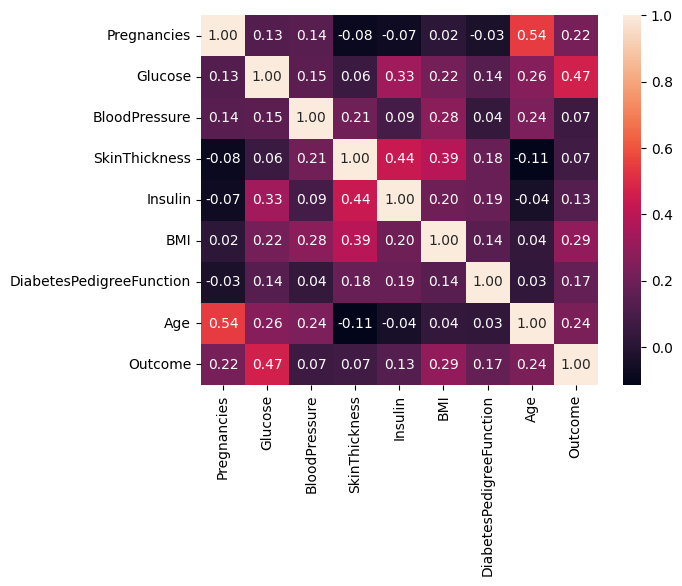

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

Glucose, BMI, and Age usually show stronger relationships with the outcome compared to other variables.

### Inferential Statistics (Hypothesis Testing)

We test whether glucose levels differ significantly between diabetic and non-diabetic patients.

In [9]:
from scipy.stats import ttest_ind

group1 = df[df['Outcome'] == 0]['Glucose']
group2 = df[df['Outcome'] == 1]['Glucose']

t_stat, p_val = ttest_ind(group1, group2)
t_stat, p_val

(np.float64(-14.600060005973894), np.float64(8.935431645289912e-43))

If the p-value is less than 0.05, we reject the null hypothesis and conclude that glucose levels significantly differ between the two groups.

### Model Diagnostics

We build a logistic regression model again and evaluate its performance.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

confusion_matrix(y_test, y_pred)

/Users/ujenamanandhar/Desktop/data-team-sharks/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ujenamanandhar/Desktop/data-team-sharks/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ujenamanandhar/Desktop/data-team-sharks/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ujenamanandhar/Desktop/data-team-sharks/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/ujenamanandhar/Desktop/data-team-sharks/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

array([[78, 21],
       [18, 37]])

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



These results help us understand how well the model is performing in terms of accuracy, precision, and recall.

### Interpretation and Validation

The hypothesis that glucose significantly affects diabetes outcome is supported if the statistical test shows a low p-value.

The model performance also supports the idea that certain features are useful predictors.

If results were weak, we could consider collecting more data through surveys or improving feature engineering.

### Conclusion

Descriptive and inferential analysis both suggest that some features like glucose and BMI are important. The model diagnostics show reasonable performance, validating our earlier assumptions.